In [114]:
from sklearn.cluster import KMeans
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt  
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [115]:
# Load the dataset
df = pd.read_csv("midterm_datasets/melb_data.csv")

In [116]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [117]:
df = df.drop(columns=["BuildingArea", "YearBuilt"])

In [118]:
df["Postcode"].fillna(df["Postcode"].median())
df.dropna(inplace=True)

In [119]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,2.0,1.0,1.0,202.0,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,2.0,1.0,0.0,156.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,0.0,134.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,1.0,94.0,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,3.0,1.0,2.0,120.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [120]:
label_cols = ["Rooms", "Price"]

In [121]:
le = LabelEncoder()

In [122]:
for col in label_cols:
    df[col] = le.fit_transform(df[col])

In [123]:
model = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42) 

In [124]:
X = df[["Address", "Postcode", "Rooms", "Price"]]

In [125]:
# Select only numeric columns from X
X_numeric = X.select_dtypes(include=[np.number])

# Scale the numeric features
X_scaled = StandardScaler().fit_transform(X_numeric)

# Perform clustering and assign cluster labels
df_cleaned['cluster'] = model.fit_predict(X_scaled)

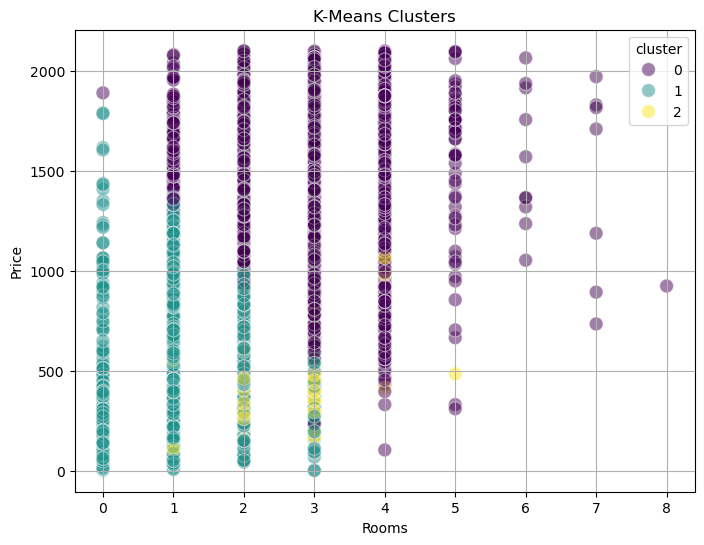

In [126]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Rooms', y='Price', hue='cluster', palette='viridis', data=df_cleaned, s=100, alpha=0.5)
plt.title(f'K-Means Clusters')
plt.xlabel('Rooms')
plt.ylabel('Price')
plt.grid(True)
plt.show()

1. Does preprocessing affect the result of the model? Why?
    - Yes, preprocessing has a substantial effect on clustering results.  Cleaning data, dealing with missing values, encoding categorical variables, and scaling features are all crucial steps in ensuring that each characteristic contributes adequately to KMeans' distance computations.  Without these phases, characteristics with greater numeric ranges may dominate the clustering process, and missing or improperly encoded data may result in incorrect or misleading cluster assignments.

2. What is your conclusion based on the interpretation or result of your model?
    - The KMeans model's clusters can help uncover underlying patterns in the housing dataset, such as groups based on the number of rooms and pricing. If the clusters show distinct and interpretable groupings, it suggests that the dataset contains meaningful segmentation. However, further validation and evaluation—such as comparing silhouette scores or visualizing clusters—are essential to confirm that these clusters are both statistically sound and useful for decision-making.